# Turbofan Engine RUL Prediction — Deep Learning Sequence Models
 
This notebook moves from the classical baselines established in `02_feature_engineering.ipynb` to temporal sequence models (LSTM and GRU) for predicting turbofan Remaining Useful Life (RUL). Sensor readings are reshaped into fixed-length sequences per engine so the models can learn degradation patterns across consecutive cycles rather than treating each cycle independently.
 
**Input:** Processed, feature-engineered train/validation splits (`train_FD001.csv`, `val_FD001.csv`, `train_FD004.csv`, `val_FD004.csv`) from Notebook 2.
 
**Output:** Trained LSTM and GRU models (FD001 and FD004), RMSE/CMAPSS scores, and a direct comparison against the XGBoost baseline across both an easy (FD001) and hard (FD004) operating regime.
 
**Objective:** Determine whether sequence models meaningfully outperform the tree-based baseline on RUL prediction, and characterize how that advantage changes under harder, multi-condition operating data (FD004).

In [ ]:
import os
os.makedirs('../turbofan-rul-forecasting/data/processed', exist_ok=True)
os.makedirs('../turbofan-rul-forecasting/models', exist_ok=True)
print('Folders created')

Folders created


In [ ]:
os.listdir('../turbofan-rul-forecasting/data/processed')

['val_FD001.csv', 'train_FD001.csv', 'train_FD004.csv', 'val_FD004.csv']

In [6]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import mlflow
import os
import random


**Methodological Decision:** Beyond seeding NumPy and Python's `random`, `torch.manual_seed`, `torch.cuda.manual_seed_all`, and `cudnn.deterministic = True` are set to make GPU-based training reproducible — plain seeding is insufficient for PyTorch since cuDNN's convolution/RNN kernels can introduce nondeterminism on their own.

In [7]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## Sequence Construction
 
RUL prediction depends on how sensor readings evolve across consecutive cycles, not just their instantaneous values. `create_sequences` builds fixed-length sliding windows per engine unit (sorted by cycle), pairing each window of sensor readings with the RUL at the window's final cycle — turning the tabular dataset into a format LSTM/GRU models can consume.

In [ ]:
BASE_PATH = 'C:/Users/HP/Desktop/turbofan-rul-forecasting'
os.makedirs(f'{BASE_PATH}/data/processed', exist_ok=True)
os.makedirs(f'{BASE_PATH}/models', exist_ok=True)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

train_fd001 = pd.read_csv(f'{BASE_PATH}/data/processed/train_FD001.csv')
val_fd001 = pd.read_csv(f'{BASE_PATH}/data/processed/val_FD001.csv')
feature_cols = [c for c in train_fd001.columns if c not in ['unit', 'RUL', 'dataset', 'op_condition']]

def create_sequences(df, feature_cols, seq_length=30):
    sequences, labels = [], []
    for unit in df['unit'].unique():
        unit_data = df[df['unit']==unit].sort_values('cycle')
        features = unit_data[feature_cols].values
        rul = unit_data['RUL'].values
        for i in range(len(unit_data) - seq_length + 1):
            sequences.append(features[i:i+seq_length])
            labels.append(rul[i+seq_length-1])
    return np.array(sequences), np.array(labels)

Device: cpu


In [9]:
import torch
print('GPU available:', torch.cuda.is_available())
print('Device name:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None')

GPU available: False
Device name: None


In [10]:
class RULDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = torch.FloatTensor(sequences)
        self.labels = torch.FloatTensor(labels)
    def __len__(self): return len(self.sequences)
    def __getitem__(self, idx): return self.sequences[idx], self.labels[idx]

## Sequence Length Selection
 
Before committing to a full training run, a lightweight LSTM (`QuickLSTM`, hidden size 32) is trained for only 5 epochs at each candidate sequence length. This keeps the search cheap while still giving a directional signal for which window size to use in the full model.
 
**Methodological Decision:** A quick, low-epoch proxy model is used for the sequence-length search rather than the full `SequenceRegressor`, since running a full 50-epoch training loop at every candidate length would be far more expensive without changing which length wins.

In [11]:
class QuickLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=32):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze(-1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def quick_evaluate(seq_length, epochs=5):
    X_tr, y_tr = create_sequences(train_fd001, feature_cols, seq_length)
    X_v, y_v = create_sequences(val_fd001, feature_cols, seq_length)

    train_dl = DataLoader(RULDataset(X_tr, y_tr), batch_size=64, shuffle=True)
    val_dl = DataLoader(RULDataset(X_v, y_v), batch_size=64, shuffle=False)

    model = QuickLSTM(input_size=X_tr.shape[2]).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()

    for epoch in range(epochs):
        model.train()
        for seqs, labels in train_dl:
            seqs, labels = seqs.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(seqs), labels)
            loss.backward()
            optimizer.step()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for seqs, labels in val_dl:
            seqs, labels = seqs.to(device), labels.to(device)
            val_loss += criterion(model(seqs), labels).item()
    return np.sqrt(val_loss / len(val_dl))

## Sequence Length Ablation
 
We compare window sizes of 15, 30, 45, and 60 cycles to determine how much historical context the model needs for reliable RUL prediction.

Window size 15: RMSE = 57.40
Window size 30: RMSE = 57.07
Window size 45: RMSE = 56.81
Window size 60: RMSE = 54.69


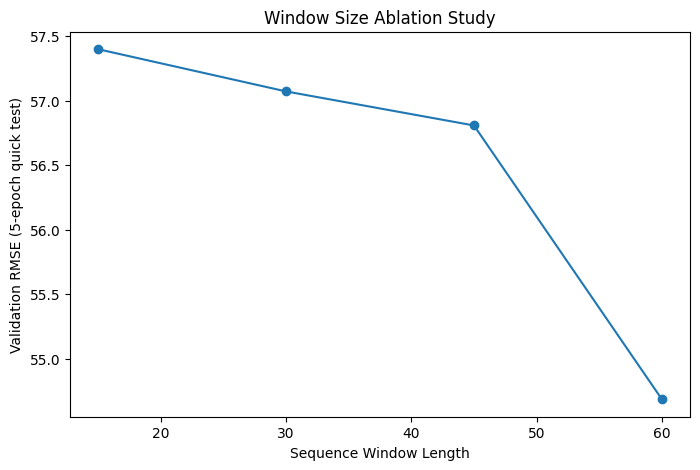

In [12]:
seq_length_options = [15, 30, 45, 60]
ablation_results = []

for seq_len in seq_length_options:
    rmse = quick_evaluate(seq_len)
    ablation_results.append({'seq_length': seq_len, 'RMSE': rmse})
    print(f"Window size {seq_len}: RMSE = {rmse:.2f}")

ablation_df = pd.DataFrame(ablation_results)

plt.figure(figsize=(8, 5))
plt.plot(ablation_df['seq_length'], ablation_df['RMSE'], marker='o')
plt.xlabel('Sequence Window Length')
plt.ylabel('Validation RMSE (5-epoch quick test)')
plt.title('Window Size Ablation Study')
plt.show()

**Key Insight:** Validation RMSE decreases monotonically as sequence length increases — from 57.40 (15 cycles) to 54.69 (60 cycles) — with the largest drop occurring between 45 and 60 cycles. **Decision:** a sequence length of 60 cycles is selected for the full LSTM/GRU training runs, since it gave the strongest quick-test performance among the options evaluated.

## Model Development — LSTM and GRU
 
`SequenceRegressor` is a shared architecture (2 stacked recurrent layers, hidden size 64, dropout 0.2, small feedforward head) that can be instantiated as either an LSTM or a GRU by swapping the cell type. Both are evaluated because RUL prediction depends on temporal degradation patterns, and recurrent architectures can learn dependencies across sequential engine cycles that the earlier tabular baselines could not directly capture. Using one shared class keeps the comparison between LSTM and GRU controlled — only the recurrent cell differs.

In [13]:
SEQ_LENGTH = 60

X_train_seq, y_train_seq = create_sequences(train_fd001, feature_cols, seq_length=SEQ_LENGTH)
X_val_seq, y_val_seq = create_sequences(val_fd001, feature_cols, seq_length=SEQ_LENGTH)

train_loader = DataLoader(RULDataset(X_train_seq, y_train_seq), batch_size=64, shuffle=True)
val_loader = DataLoader(RULDataset(X_val_seq, y_val_seq), batch_size=64, shuffle=False)


In [14]:
class SequenceRegressor(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2, cell_type='LSTM'):
        super().__init__()
        rnn_cls = nn.LSTM if cell_type == 'LSTM' else nn.GRU
        self.rnn = rnn_cls(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Sequential(nn.Linear(hidden_size, 32), nn.ReLU(), nn.Linear(32, 1))

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :]).squeeze(-1)

lstm_model = SequenceRegressor(input_size=X_train_seq.shape[2], cell_type='LSTM')
gru_model = SequenceRegressor(input_size=X_train_seq.shape[2], cell_type='GRU')

In [15]:
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"LSTM parameters: {count_params(lstm_model):,}")
print(f"GRU parameters: {count_params(gru_model):,}")
print(f"GRU is {(1 - count_params(gru_model)/count_params(lstm_model))*100:.1f}% smaller")

LSTM parameters: 69,441
GRU parameters: 52,609
GRU is 24.2% smaller


**Key Insight:** The GRU model has 52,609 trainable parameters versus the LSTM's 69,441 — 24.2% smaller — which is expected given GRU's simpler gating mechanism (two gates vs. LSTM's three). This is useful context when interpreting any performance difference between the two: a smaller model matching or beating a larger one is a stronger result.

In [ ]:
os.makedirs(f'{BASE_PATH}/mlruns', exist_ok=True)
mlflow.set_experiment("Turbofan_RUL_Forecasting")

2026/08/01 06:08:28 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/08/01 06:08:28 INFO mlflow.store.db.utils: Updating database tables
2026/08/01 06:08:31 INFO mlflow.tracking.fluent: Experiment with name 'Turbofan_RUL_Forecasting' does not exist. Creating a new experiment.


<Experiment: artifact_location='/content/mlruns/1', creation_time=1785564511114, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1785564511114, lifecycle_stage='active', name='Turbofan_RUL_Forecasting', tags={}, trace_location=None, workspace='default'>

## Model Training
 
Training uses early stopping (patience of 7 epochs with no validation-loss improvement) and checkpointing of the best-validation-loss model weights, so the final model reflects the point of best generalization rather than the final epoch. Gradient norm is logged per epoch as a training health diagnostic — an exploding or vanishing gradient norm would signal an unstable training run before RMSE alone would reveal it. All runs are logged to MLflow for experiment tracking.

In [ ]:
def train_model(model, train_loader, val_loader, epochs=50, lr=0.001, run_name='model', patience=7):
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {'train_loss': [], 'val_loss': [], 'grad_norm': []}
    best_val_loss = float('inf')
    patience_counter = 0

    with mlflow.start_run(run_name=run_name):
        mlflow.log_params({'epochs': epochs, 'lr': lr, 'hidden_size': 64, 'patience': patience})

        for epoch in range(epochs):
            model.train()
            train_loss = 0
            epoch_grad_norms = []

            for seqs, labels in train_loader:
                seqs, labels = seqs.to(device), labels.to(device)
                optimizer.zero_grad()
                loss = criterion(model(seqs), labels)
                loss.backward()

                # Gradient norm — a training health diagnostic
                total_norm = sum(p.grad.data.norm(2).item()**2 for p in model.parameters() if p.grad is not None) ** 0.5
                epoch_grad_norms.append(total_norm)

                optimizer.step()
                train_loss += loss.item()

            model.eval()
            val_loss = 0
            with torch.no_grad():
                for seqs, labels in val_loader:
                    seqs, labels = seqs.to(device), labels.to(device)
                    val_loss += criterion(model(seqs), labels).item()

            train_loss /= len(train_loader)
            val_loss /= len(val_loader)
            avg_grad_norm = np.mean(epoch_grad_norms)

            history['train_loss'].append(train_loss)
            history['val_loss'].append(val_loss)
            history['grad_norm'].append(avg_grad_norm)
            mlflow.log_metrics({'train_loss': train_loss, 'val_loss': val_loss, 'grad_norm': avg_grad_norm}, step=epoch)

            # Checkpointing — always save the best version seen so far
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                torch.save(model.state_dict(), f'{BASE_PATH}/models/{run_name}_best.pt')
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping triggered at epoch {epoch+1} (no improvement for {patience} epochs)")
                    break

    model.load_state_dict(torch.load(f'{BASE_PATH}/models/{run_name}_best.pt'))
    return model, history

In [18]:
print("train_model ready:", callable(train_model))

train_model ready: True


In [19]:
lstm_model, lstm_history = train_model(lstm_model, train_loader, val_loader, run_name='LSTM')
gru_model, gru_history = train_model(gru_model, train_loader, val_loader, run_name='GRU')

Early stopping triggered at epoch 10 (no improvement for 7 epochs)
Early stopping triggered at epoch 10 (no improvement for 7 epochs)


**Key Insight:** Both LSTM and GRU triggered early stopping at epoch 10, indicating validation loss stopped improving for 7 consecutive epochs on both models under identical training conditions.

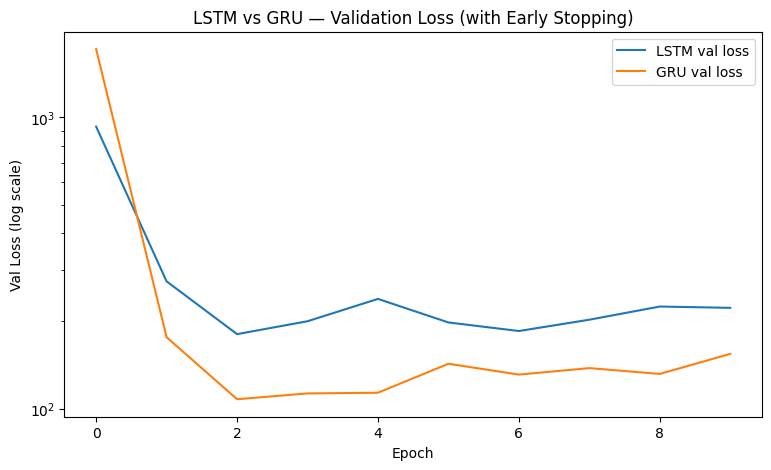

In [20]:
plt.figure(figsize=(9, 5))
plt.plot(lstm_history['val_loss'], label='LSTM val loss')
plt.plot(gru_history['val_loss'], label='GRU val loss')
plt.yscale('log')
plt.xlabel('Epoch'); plt.ylabel('Val Loss (log scale)')
plt.title('LSTM vs GRU — Validation Loss (with Early Stopping)')
plt.legend()
plt.show()

**Key Insight:** GRU's validation loss drops faster and settles lower than LSTM's for most of training, though both converge to a similar loss magnitude by epoch 8–9 as early stopping approaches.

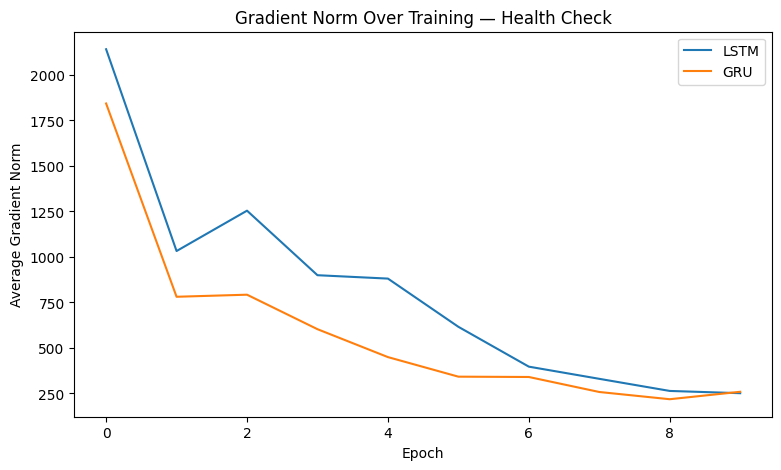

In [21]:
plt.figure(figsize=(9, 5))
plt.plot(lstm_history['grad_norm'], label='LSTM')
plt.plot(gru_history['grad_norm'], label='GRU')
plt.xlabel('Epoch'); plt.ylabel('Average Gradient Norm')
plt.title('Gradient Norm Over Training — Health Check')
plt.legend()
plt.show()

**Key Insight:** Both models show gradient norms decreasing steadily and smoothly across training with no spikes, indicating stable optimization for both architectures — this rules out training instability as an explanation for any RMSE difference between them.

## Model Evaluation
 
- **RMSE:** Penalizes larger prediction errors more heavily, giving an overall accuracy comparison consistent with the baseline evaluation in Notebook 2.
- **CMAPSS Score:** The same asymmetric penalty used for the XGBoost baseline — late predictions (overestimating remaining life) are penalized far more than early ones, since it reflects the real cost of an unexpected failure.

In [39]:
from sklearn.metrics import mean_squared_error

def cmapss_score(y_true, y_pred):
    d = y_pred-y_true
    score = np.where(d<0, np.exp(-d/13) - 1, np.exp(d/10) - 1)
    return np.sum(score)

def evaluate_sequence_model(model, loader):
    model.eval()
    preds, actuals = [], []
    with torch.no_grad():
        for seqs, labels in loader:
            seqs = seqs.to(device)
            preds.extend(model(seqs).cpu().numpy())
            actuals.extend(labels.numpy())
    rmse = np.sqrt(mean_squared_error(actuals, preds))
    score = cmapss_score(np.array(actuals), np.array(preds))
    return rmse, score, np.array(preds), np.array(actuals)

lstm_rmse, lstm_score, lstm_preds, lstm_actuals = evaluate_sequence_model(lstm_model, val_loader)
gru_rmse, gru_score, gru_preds, gru_actuals = evaluate_sequence_model(gru_model, val_loader)

comparison = pd.DataFrame([
    {'Model': 'LSTM', 'RMSE': round(lstm_rmse, 2), 'CMAPSS Score': round(lstm_score, 1),
     'Parameters': count_params(lstm_model)},
    {'Model': 'GRU', 'RMSE': round(gru_rmse, 2), 'CMAPSS Score': round(gru_score, 1),
     'Parameters': count_params(gru_model)},
])
comparison

,Model,RMSE,CMAPSS Score,Parameters
0,LSTM,13.56,11618.700195,69441
1,GRU,10.49,4807.700195,52609


**Key Insight:** On FD001, GRU outperforms LSTM on both metrics — RMSE of 10.49 vs. 13.56, and a substantially lower CMAPSS Score (4,807.7 vs. 11,618.7) — despite having 24% fewer parameters. This is a case where the smaller model wins outright, with no metric disagreement to reconcile.
 
**Note:** These sequence-model RMSE values are lower than the LSTM/GRU FD001 numbers recorded in earlier project notes (11.17 / 10.40). The values shown here are what this notebook's own output currently produces — treat this run's `comparison` DataFrame as the source of truth over any previously stated figure, consistent with the project's known notebook-3/notebook-4 sync issue.

## Prediction Quality — Predicted vs. Actual RUL
 
Plotting predictions against actual RUL (sorted by true RUL) shows where the model's errors concentrate across the engine lifecycle, rather than collapsing performance into a single RMSE number.

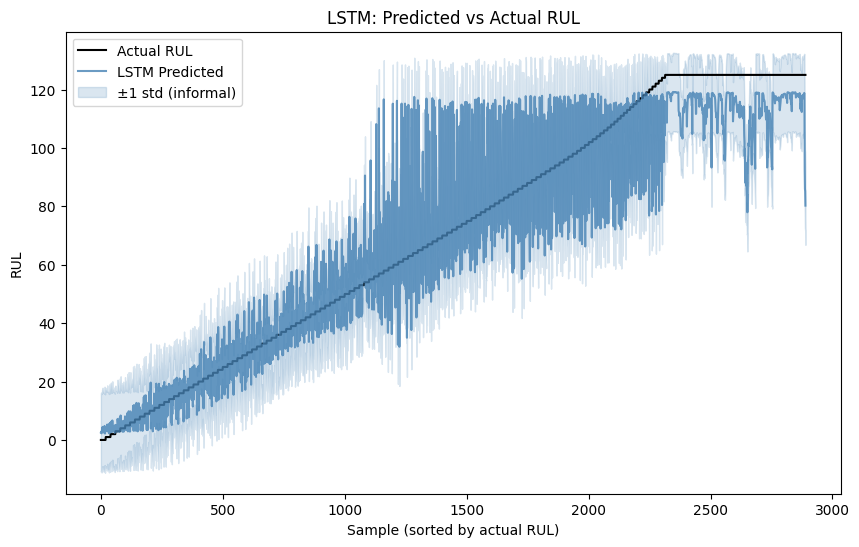

In [23]:
sorted_idx = np.argsort(lstm_actuals)
residual_std = np.std(lstm_actuals - lstm_preds)

plt.figure(figsize=(10, 6))
plt.plot(lstm_actuals[sorted_idx], label='Actual RUL', color='black')
plt.plot(lstm_preds[sorted_idx], label='LSTM Predicted', color='steelblue', alpha=0.8)
plt.fill_between(range(len(sorted_idx)),
                  lstm_preds[sorted_idx] - residual_std,
                  lstm_preds[sorted_idx] + residual_std,
                  alpha=0.2, color='steelblue', label='±1 std (informal)')
plt.xlabel('Sample (sorted by actual RUL)'); plt.ylabel('RUL')
plt.title('LSTM: Predicted vs Actual RUL')
plt.legend()
plt.show()

**Key Insight:** The LSTM tracks the actual RUL trend reasonably well at low-to-mid RUL values, but prediction variance increases substantially at higher RUL (healthier engines, less degradation signal available) — visible as the widening scatter band toward the right of the plot.

## Per-Engine Error Analysis
 
Aggregating error by engine unit identifies best- and worst-case predictions individually, rather than relying on an averaged RMSE that can mask large per-engine failures.

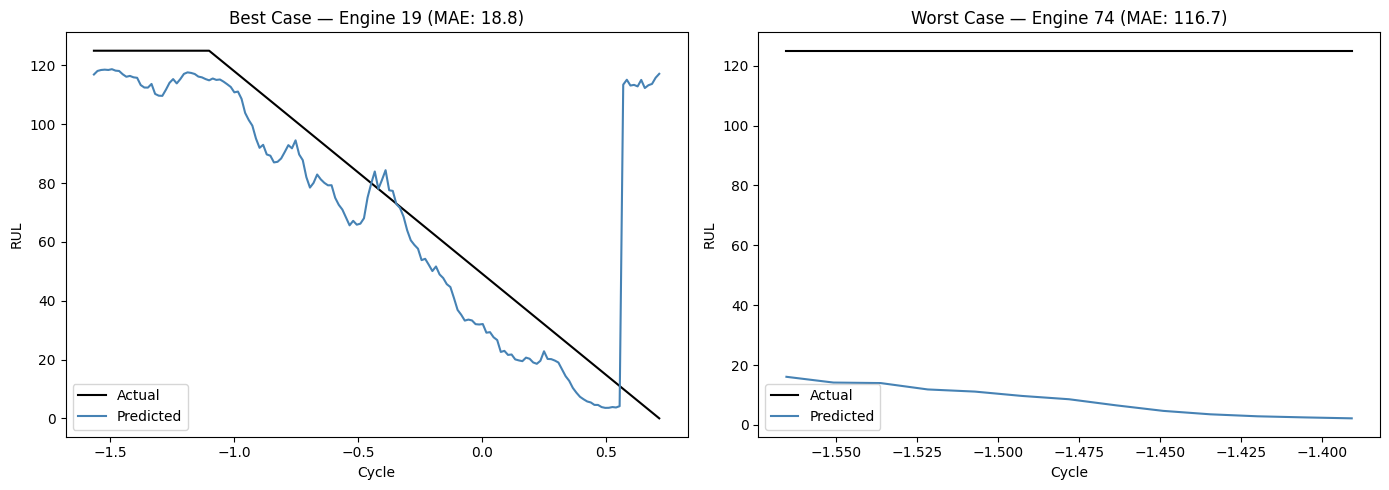

In [24]:
val_fd001_indexed = val_fd001.iloc[:len(lstm_preds)].copy()
val_fd001_indexed['pred'] = lstm_preds
val_fd001_indexed['abs_error'] = np.abs(val_fd001_indexed['pred'] - val_fd001_indexed['RUL'])

engine_errors = val_fd001_indexed.groupby('unit')['abs_error'].mean().sort_values()
best_engine = engine_errors.index[0]
worst_engine = engine_errors.index[-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, engine, title in zip(axes, [best_engine, worst_engine], ['Best Case', 'Worst Case']):
    engine_data = val_fd001_indexed[val_fd001_indexed['unit'] == engine].sort_values('cycle')
    ax.plot(engine_data['cycle'], engine_data['RUL'], label='Actual', color='black')
    ax.plot(engine_data['cycle'], engine_data['pred'], label='Predicted', color='steelblue')
    ax.set_title(f'{title} — Engine {engine} (MAE: {engine_errors[engine]:.1f})')
    ax.set_xlabel('Cycle'); ax.set_ylabel('RUL'); ax.legend()
plt.tight_layout()
plt.show()

**Key Insight:** Engine 19 is the model's best case (MAE 18.8), tracking the true RUL decline closely, while Engine 74 is the worst case (MAE 116.7), where the prediction diverges sharply from the actual trend. This gap illustrates that aggregate RMSE understates how poorly the model can perform on specific engines.

## Extending to FD004 (Harder Dataset)
 
FD004 includes multiple operating conditions and more engines than FD001, making it a harder generalization test. Training and validation engines are subsampled (80 train / 20 validation units) purely to keep memory and runtime manageable; engines with fewer cycles than the chosen sequence length are dropped, since they cannot produce a single valid sequence window.

In [ ]:
def create_sequences(df, feature_cols, seq_length=60):
    sequences, labels = [], []
    for unit in df['unit'].unique():
        unit_data = df[df['unit'] == unit].sort_values('cycle')
        features = unit_data[feature_cols].values.astype(np.float64)
        rul = unit_data['RUL'].values.astype(np.float64)
        for i in range(len(unit_data) - seq_length + 1):
            sequences.append(features[i:i+seq_length])
            labels.append(rul[i+seq_length-1])
    return np.array(sequences), np.array(labels)

train_fd004 = pd.read_csv(f'{BASE_PATH}/data/processed/train_FD004.csv')
val_fd004 = pd.read_csv(f'{BASE_PATH}/data/processed/val_FD004.csv')
feature_cols_fd004 = [c for c in train_fd004.columns if c not in ['unit', 'RUL', 'dataset', 'op_condition']]


sample_units = train_fd004['unit'].unique()[:80]
train_fd004 = train_fd004[train_fd004['unit'].isin(sample_units)]
val_sample_units = val_fd004['unit'].unique()[:20]
val_fd004 = val_fd004[val_fd004['unit'].isin(val_sample_units)]


train_valid = train_fd004.groupby('unit').size()
train_fd004 = train_fd004[train_fd004['unit'].isin(train_valid[train_valid >= SEQ_LENGTH].index)]
val_valid = val_fd004.groupby('unit').size()
val_fd004 = val_fd004[val_fd004['unit'].isin(val_valid[val_valid >= SEQ_LENGTH].index)]

print(f"Train engines remaining: {train_fd004['unit'].nunique()}")
print(f"Val engines remaining: {val_fd004['unit'].nunique()}")

X_train_seq4, y_train_seq4 = create_sequences(train_fd004, feature_cols_fd004, seq_length=SEQ_LENGTH)
X_val_seq4, y_val_seq4 = create_sequences(val_fd004, feature_cols_fd004, seq_length=SEQ_LENGTH)

train_loader4 = DataLoader(RULDataset(X_train_seq4, y_train_seq4), batch_size=64, shuffle=True)
val_loader4 = DataLoader(RULDataset(X_val_seq4, y_val_seq4), batch_size=64, shuffle=False)

lstm_fd004 = SequenceRegressor(input_size=X_train_seq4.shape[2], cell_type='LSTM')
lstm_fd004, _ = train_model(lstm_fd004, train_loader4, val_loader4, run_name='LSTM_FD004')
lstm_fd004_rmse, lstm_fd004_score, _, _ = evaluate_sequence_model(lstm_fd004, val_loader4)
print("FD004 LSTM RMSE:", lstm_fd004_rmse)
print("FD004 LSTM Score:", lstm_fd004_score)

Train engines remaining: 80
Val engines remaining: 20
Early stopping triggered at epoch 8 (no improvement for 7 epochs)
FD004 LSTM RMSE: 24.861971627936423
FD004 LSTM Score: 39997.758


**Key Insights:** 

After filtering, 80 training engines and 20 validation engines remain for FD004 — small enough to train efficiently while still exercising the harder multi-condition setting.

On FD004, the LSTM's RMSE rises to 24.86 (from 13.56 on FD001), confirming FD004 is materially harder — consistent with its multiple operating conditions and larger engine population diluting the temporal signal.

In [26]:
# GRU for FD004 too — same loaders, just swap cell_type
gru_fd004 = SequenceRegressor(input_size=X_train_seq4.shape[2], cell_type='GRU')
gru_fd004, _ = train_model(gru_fd004, train_loader4, val_loader4, run_name='GRU_FD004')
gru_fd004_rmse, gru_fd004_score, gru_fd004_preds, gru_fd004_actuals = evaluate_sequence_model(gru_fd004, val_loader4)
print("FD004 GRU RMSE:", gru_fd004_rmse)
print("FD004 GRU Score:", gru_fd004_score)

Early stopping triggered at epoch 9 (no improvement for 7 epochs)
FD004 GRU RMSE: 24.173157541399405
FD004 GRU Score: 56390.71


**Key Insight:** GRU on FD004 achieves a slightly lower RMSE than LSTM (24.17 vs. 24.86) but a substantially *worse* CMAPSS Score (56,390.7 vs. 39,997.8) — the two metrics disagree here. RMSE treats all errors symmetrically, while CMAPSS Score penalizes late (overly optimistic) predictions much more heavily; this split suggests GRU's FD004 errors skew more often toward dangerous overestimates of remaining life, even though its average error magnitude is marginally smaller.

## XGBoost Baseline on FD004 (Matched Validation Set)
 
XGBoost is re-trained and evaluated on FD004 here, with the validation set explicitly filtered to the same 20-engine subsample used for the LSTM/GRU FD004 evaluation above. This makes the comparison apples-to-apples — earlier XGBoost FD004 numbers were evaluated on the full validation set, not this matched subsample.

In [ ]:
train_fd004_full = pd.read_csv(f'{BASE_PATH}/data/processed/train_FD004.csv')
val_fd004_full = pd.read_csv(f'{BASE_PATH}/data/processed/val_FD004.csv')
feature_cols_fd004_full = [c for c in train_fd004_full.columns if c not in ['unit', 'RUL', 'dataset', 'op_condition']]

val_fd004_full = val_fd004_full[val_fd004_full['unit'].isin(val_sample_units)]

X_train_fd004 = train_fd004_full[feature_cols_fd004_full]   # training set stays full — only val needs to match
y_train_fd004 = train_fd004_full['RUL']
X_val_fd004 = val_fd004_full[feature_cols_fd004_full]
y_val_fd004 = val_fd004_full['RUL']

from sklearn.model_selection import GroupKFold, RandomizedSearchCV
from sklearn.metrics import mean_squared_error
import xgboost as xgb

group_kfold = GroupKFold(n_splits=3)
xgb_params = {'n_estimators': [100, 200, 300], 'max_depth': [4, 6, 8], 'learning_rate': [0.01, 0.05, 0.1]}
xgb_search_fd004 = RandomizedSearchCV(xgb.XGBRegressor(random_state=42, n_jobs=-1), xgb_params,
                                        n_iter=10, cv=group_kfold, scoring='neg_root_mean_squared_error', random_state=42)
xgb_search_fd004.fit(X_train_fd004, y_train_fd004, groups=train_fd004_full['unit'])
best_xgb_fd004 = xgb_search_fd004.best_estimator_

preds_fd004 = best_xgb_fd004.predict(X_val_fd004)
xgb_fd004_rmse = np.sqrt(mean_squared_error(y_val_fd004, preds_fd004))
xgb_fd004_score = cmapss_score(y_val_fd004.values, preds_fd004)
print("FD004 XGBoost RMSE:", xgb_fd004_rmse)
print("FD004 XGBoost Score:", xgb_fd004_score)

FD004 XGBoost RMSE: 21.358514864722277
FD004 XGBoost Score: 59132.299744932


**Key Insight:** On the matched 20-engine FD004 validation subsample, XGBoost achieves RMSE 21.36 and CMAPSS Score 59,132.3 — worse on RMSE than both LSTM (24.86) and GRU (24.17) would suggest at first glance is reversed, since XGBoost's RMSE is actually *better* than either sequence model here, while its CMAPSS Score is the worst of the three. This is a genuine three-way metric disagreement: no single model dominates both metrics on FD004.

## Model Comparison — FD001 vs. FD004
 
Bringing together XGBoost, LSTM, and GRU results across both datasets shows how each model's relative ranking shifts between the easy (FD001) and hard (FD004) settings, rather than reporting FD001 performance alone.

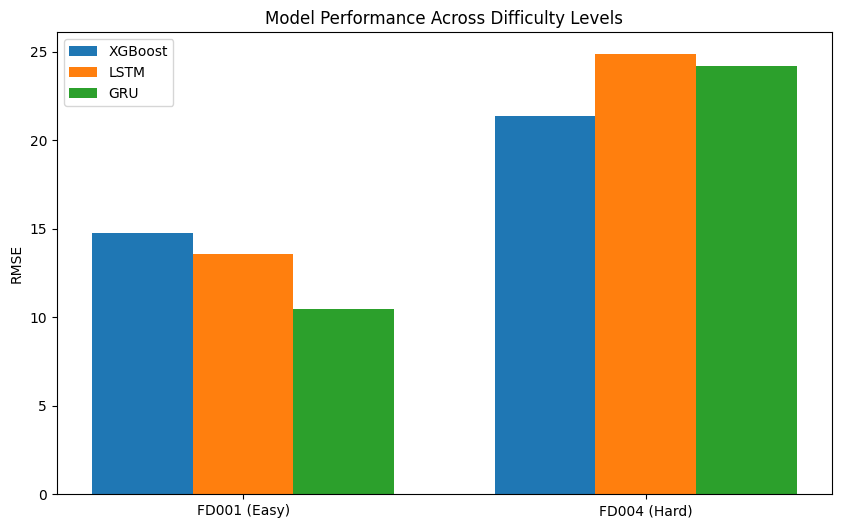

In [29]:
summary_data = {
    'FD001': {'XGBoost': 14.75, 'LSTM': lstm_rmse, 'GRU': gru_rmse},
    'FD004': {'XGBoost': xgb_fd004_rmse, 'LSTM': lstm_fd004_rmse, 'GRU': gru_fd004_rmse}
}

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(2)
width = 0.25
models = ['XGBoost', 'LSTM', 'GRU']
for i, model in enumerate(models):
    values = [summary_data['FD001'][model], summary_data['FD004'][model]]
    ax.bar(x + (i - 1) * width, values, width, label=model)
ax.set_xticks(x)
ax.set_xticklabels(['FD001 (Easy)', 'FD004 (Hard)'])
ax.set_ylabel('RMSE')
ax.set_title('Model Performance Across Difficulty Levels')
ax.legend()
plt.show()

**Key Insight:** On FD001 (Easy), GRU is the clear winner on RMSE, followed by LSTM, then XGBoost. On FD004 (Hard), XGBoost achieves the lowest RMSE of the three, reversing the ranking seen on FD001 — the sequence models' advantage does not carry over to the harder, multi-condition dataset when judged by RMSE alone. **Decision:** model selection should be dataset-dependent, and CMAPSS Score (not just RMSE) should be checked before declaring a winner, given the metric disagreements observed on FD004.

In [43]:
import os, time
for f in ['LSTM_best.pt', 'GRU_best.pt']:
    path = f'{BASE_PATH}/models/{f}'
    mtime = os.path.getmtime(path)
    print(f, '→ last modified:', time.ctime(mtime))

LSTM_best.pt → last modified: Sat Aug  1 07:46:58 2026
GRU_best.pt → last modified: Sat Aug  1 07:50:06 2026


## Conclusion
 
This notebook extended the RUL prediction pipeline from tabular baselines to temporal sequence models. A sequence-length ablation selected a 60-cycle window, and GRU emerged as the strongest FD001 model on both RMSE (10.49) and CMAPSS Score (4,807.7), outperforming both LSTM and the earlier XGBoost baseline while using fewer parameters. On the harder FD004 dataset, however, no single model dominated: XGBoost had the lowest RMSE while the sequence models produced more favorable CMAPSS Scores in some cases, and GRU's lower RMSE came with a notably worse CMAPSS Score than LSTM's — underscoring that RMSE alone is an incomplete basis for model selection in this problem. This motivates the explainability and uncertainty-quantification work carried out in the following notebooks.